In [64]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.api import CompareMeans, DescrStatsW
from scipy.stats import t

Имеется таблица, содержащая информацию о событии, пользователе, прибыли от него и принадлежности его к определенной выборке.

# Цель:
Повысить среднюю прибыль от каждого пользователя. Наше предположение, что дизайн сайта, на котором была собрана выборка B, мотивирует пользователя в среднем платить больше (если сравнивать с дизайном A).
# Метрика:
Исходя из цели идеально подойдет метрика ARPU (Average Revenue Per User), так как нас интересует именно увелечение средней прибыли от пользователя.
# Гипотеза
Если изменить дизайн сайта (выборка A - до изменения, B - после), то прибыль от каждого пользователя увеличится, так как более приятный дизайн создает комфортную для пользователя атмосферу, тем самым подталкивая пользователя к покупке.
- Нулевая гипотеза: результаты в обоих выборках получились случайно и нет статистически значимой разницы между ARPU у двух разных дизайнов.
- Альтернативная гипотеза: есть статистически значимая разница между ARPU у двух разных дизайнов, причем относительное увелечение средней прибыли по пользователю более чем в 1.5 раза раза при переходе на дизайн B.\

Закрепим уровень значимости $\alpha$ равным 0.05. То есть мы хотим, чтобы вероятность того, что мы неверно отвергли нулевую гипотезу, не превышала 5%.

In [65]:
alpha = 0.05

In [66]:
dframe = pd.read_csv("AB_Test_Results.csv", delimiter=',')

In [67]:
dframe

,USER_ID,NAME,REVENUE
0,737,A,0.0
1,2423,B,0.0
2,9411,B,0.0
3,7311,B,0.0
4,6174,A,0.0
...,...,...,...
9995,1981,B,0.0
9996,502,A,0.0
9997,9214,A,0.0
9998,7741,B,0.0


In [68]:
dframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   USER_ID  10000 non-null  int64  
 1   NAME     10000 non-null  object 
 2   REVENUE  10000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 234.5+ KB


In [69]:
indep = dframe.groupby(['USER_ID', 'NAME']).count()
indep

REVENUE
USER_ID NAME         
2       B           3
3       A           2
        B           1
4       A           1
5       A           1
...               ...
9996    A           1
        B           1
9998    B           1
10000   A           2
        B           1

[7865 rows x 1 columns]

In [70]:
users_A = set(dframe[dframe['NAME'] == 'A']['USER_ID'])
users_B = set(dframe[dframe['NAME'] == 'B']['USER_ID'])

overlapping = users_A & users_B
print(f"Количество пользователей, которые есть в обеих группах: {len(overlapping)}")

Количество пользователей, которые есть в обеих группах: 1541


Видим, что выборки не являются независимыми - это проблема, A/B тест проводить нельзя. Была нарушена процедура сбора данных. Попробуем исправить ситуацию - удалим все пересечения.

In [71]:
dframe = dframe[~dframe['USER_ID'].isin(overlapping)]
dframe

,USER_ID,NAME,REVENUE
0,737,A,0.0
4,6174,A,0.0
5,2380,A,0.0
7,9168,B,0.0
9,7548,B,0.0
...,...,...,...
9993,2400,A,0.0
9994,3129,B,0.0
9996,502,A,0.0
9998,7741,B,0.0


Наша цель - увеличить прибыль от пользователей в общем. Для корректности теста сгруппируем по пользователю. Прибыль от него суммируется, а название выборки остается тем же, поэтому перем просто первую ячейку.

In [72]:
dframe = dframe.groupby('USER_ID').agg({'NAME': 'first','REVENUE': 'sum'})
dframe

,NAME,REVENUE
USER_ID,,
2,B,0.0
4,A,0.0
5,A,0.0
6,A,0.0
9,A,0.0
...,...,...
9990,A,0.0
9992,B,0.0
9993,B,0.0


In [73]:
B_data = dframe[dframe['NAME'] == 'B'].drop(columns = ['NAME'])
A_data = dframe[dframe['NAME'] == 'A'].drop(columns = ['NAME'])

In [74]:
B_data

,REVENUE
USER_ID,
2,0.0
11,0.0
12,0.0
13,0.0
21,0.0
...,...
9980,0.0
9989,0.0
9992,0.0


In [75]:
A_data

,REVENUE
USER_ID,
4,0.0
5,0.0
6,0.0
9,0.0
15,0.0
...,...
9975,0.0
9983,0.0
9986,0.0


Видим, что размеры выборок не равны. Посмотри на дисбаланс:

In [76]:
B_A_error = (len(A_data) - len(B_data)) / len(B_data)
print(f"Дисбаланс выборок: {round(B_A_error * 100, 2)}%")

Дисбаланс выборок: 0.13%


Видим, что дисбаланс всего 0.13% - некритично для проведения A/B теста.

Посмотрим на boxplot

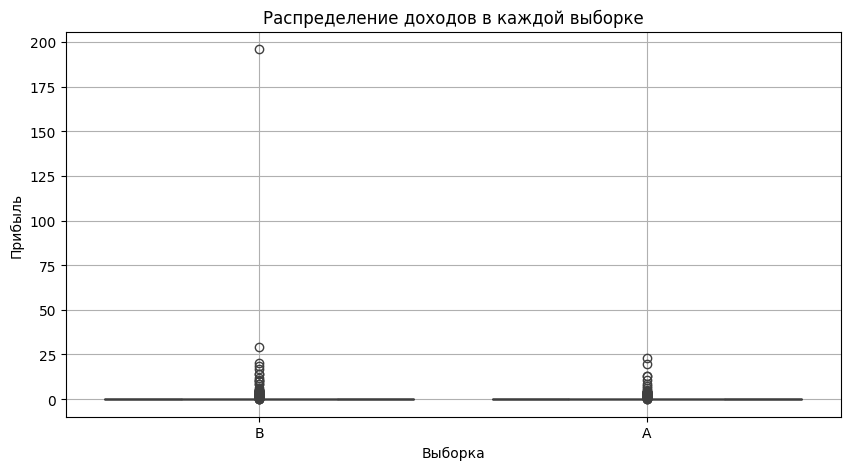

In [77]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=dframe, x="NAME", y="REVENUE", notch=True)
plt.grid()
plt.title("Распределение доходов в каждой выборке")
plt.xlabel('Выборка')
plt.ylabel('Прибыль')
plt.show()

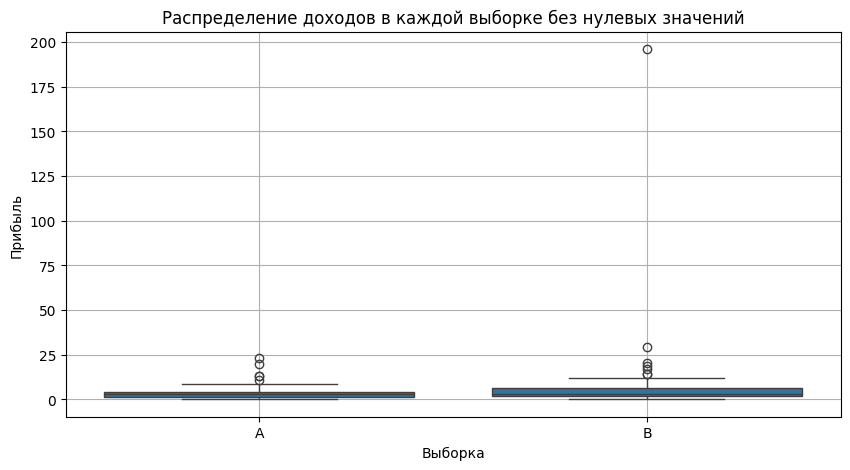

In [78]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=dframe[dframe['REVENUE'] != 0], x="NAME", y="REVENUE")
plt.grid()
plt.title("Распределение доходов в каждой выборке без нулевых значений")
plt.xlabel('Выборка')
plt.ylabel('Прибыль')
plt.show()

Видим огромное число нулевых значений - обе выборки имеют Пуассоновское распределение, что нормально для таких данных - лишь малый процент просмотревших сайт людей готовы совершить покупку.

Посмотрим среднее значение:

In [79]:
B_avg = B_data['REVENUE'].mean()
A_avg = A_data['REVENUE'].mean()

print("Средняя прибыль выборки B:", round(B_avg, 3))
print("Средняя прибыль выборки A:", round(A_avg, 3))

Средняя прибыль выборки B: 0.197
Средняя прибыль выборки A: 0.075


In [80]:
relative_revenue = (B_avg - A_avg) / A_avg
print(f"Относительное увелечение средней прибыли по пользователю: {round(relative_revenue, 3)}")

Относительное увелечение средней прибыли по пользователю: 1.627


Видим, что среднее значение у B выше, причем относительное увелечение средней прибыли по пользователю более чем в 1.5 раза. Это может быть случайностью, поэтому и проведем A/B тест, чтобы узнать вероятность такого сценария.

In [81]:
TtestResult = ttest_ind(B_data['REVENUE'], A_data['REVENUE'], equal_var=False, alternative='greater')
TtestResult

TtestResult(statistic=1.3996978409515475, pvalue=0.08086177819388471, df=2590.554714694372)

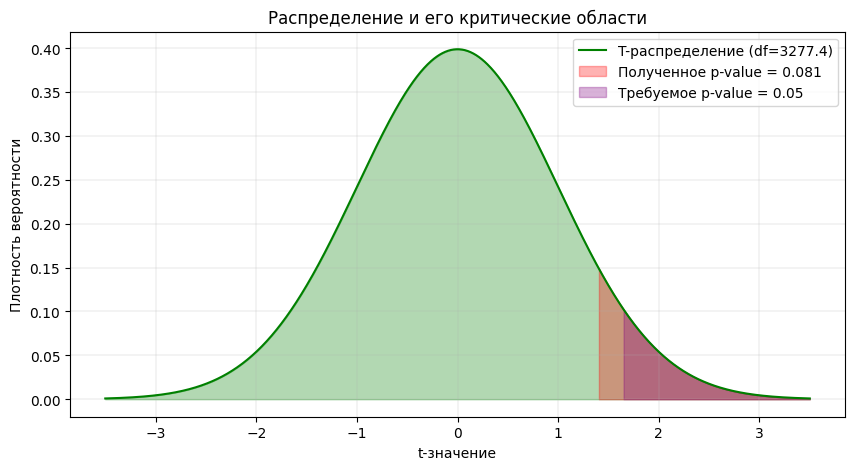

In [82]:
t_stat = TtestResult[0] 
df = 3277.3923073352767

T_dist = t(df=df)
x = np.linspace(-3.5, 3.5, 1000)
y = T_dist.pdf(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, c='green', label=f'T-распределение (df={df:.1f})')
plt.fill_between(x, y, color='green', alpha=0.3)

mask = x >= t_stat  
plt.fill_between(x[mask], y[mask], color='red', alpha=0.3, 
                 label=f'Полученное p-value = {TtestResult[1]:.3f}')

mask_5 = x >= t.ppf(0.95, df = df)
plt.fill_between(x[mask_5], y[mask_5], color='purple', alpha=0.3, 
                 label=f'Требуемое p-value = 0.05')

plt.grid(linewidth=0.2)
plt.legend()
plt.title('Распределение и его критические области')
plt.xlabel('t-значение')
plt.ylabel('Плотность вероятности')
plt.show()

Видим, что pvalue > 0.05, нам это не дает отвергуть нулевую гипотезу. Однако, нужно еще посмотреть на доверительный инетервал.

In [83]:
cm = CompareMeans(DescrStatsW(B_data['REVENUE']), DescrStatsW(A_data['REVENUE']))
print(cm.tconfint_diff(usevar='unequal'))

(-0.048894261921750545, 0.29279786500396204)


# Итог 
В ходе эксперемнта мы видим увидели относительное увелечение средней прибыли по пользователю в 1.627 раза. Но данное увелчение не является статистическим значимым, так как при сравнение средних двух выборов мы получили p-value = 0.081, что больше заданного уровня значимости равного 0.05. Кроме того мы проверили доверительный интервал - значения, на которые могут отличаться средние наших выборок (с вероятностью 95%). Видим, что нижняя граница отрицательная, то есть ноль входит в доверительный интервал. Это говори о том, что с вероятностью 95% нет разницы между средними значениями в двух выборках. Это еще одно подтверждение того, что мы не можем отвергнуть нашу нулевую гипотезу об отсутствии статистически значимой разницы между ARPU в выборках A и B.

# Пути решения проблемы:
- Повышения риска: можно рискнуть и повышить шанс ошибки. Если внедрение дизайна не сильно сложно, тогда это приемлемый вариант. По графику видно, что для этого достаточно увеличить уровень значимости в два раза, то есть сделать равным 0.10. В таком случае нужно будет учесть выброс на boxplot'ax в выборке B.
- Повторный сбор данных: в собранных данных были замечены пересечения выборок. Для данной задачи это недопустимо, возможно, были и другие нарушения в сборе данных.
- Подбор иного дизайна: возможно новый дизайн и правда не так хорош, поэтому нужно найти новый.